# Migrating Ice Wall

Issue [#2](https://github.com/bradlipovsky/allan-hills-stratigraphy/issues/2) asks whether a slowly migrating leeward drift can act as the surface analogue of a traveling basal slippery patch. This notebook compares no anomaly, a fixed accumulation–scour dipole, and a dipole that migrates 3 km over 100 kyr. The observational target is vertical: approximately 5 Ma ice lies above Pleistocene ice, with older ice below.

## Model and limits

Icepack's one-dimensional shallow-ice model solves the diagnostic velocity and prognostic thickness equations on a gently sloping, flat bed. The surface forcing is a mass-balanced pair of Gaussian ablation and accumulation zones. Pre-existing layers are advected with the modeled depth-averaged horizontal velocity; vertical velocity follows plug-flow incompressibility, $w=-z\,\partial u/\partial x$. Particles crossing the surface are removed.

This is an intentionally kinematic first test. It does not model atmospheric drift physics, fabric, isotope diffusion, or a complete vertical shear profile. The 100 kyr wall-building time is a hypothesis, not an observation. Following [Waddington et al. (2001)](https://doi.org/10.3189/172756501781831756), the decisive question is whether the wall seeds a wrinkle that passes through vertical and overturns, rather than merely tilting continuous layers.

Icepack 1.1.0; Firedrake 0.14.dev0


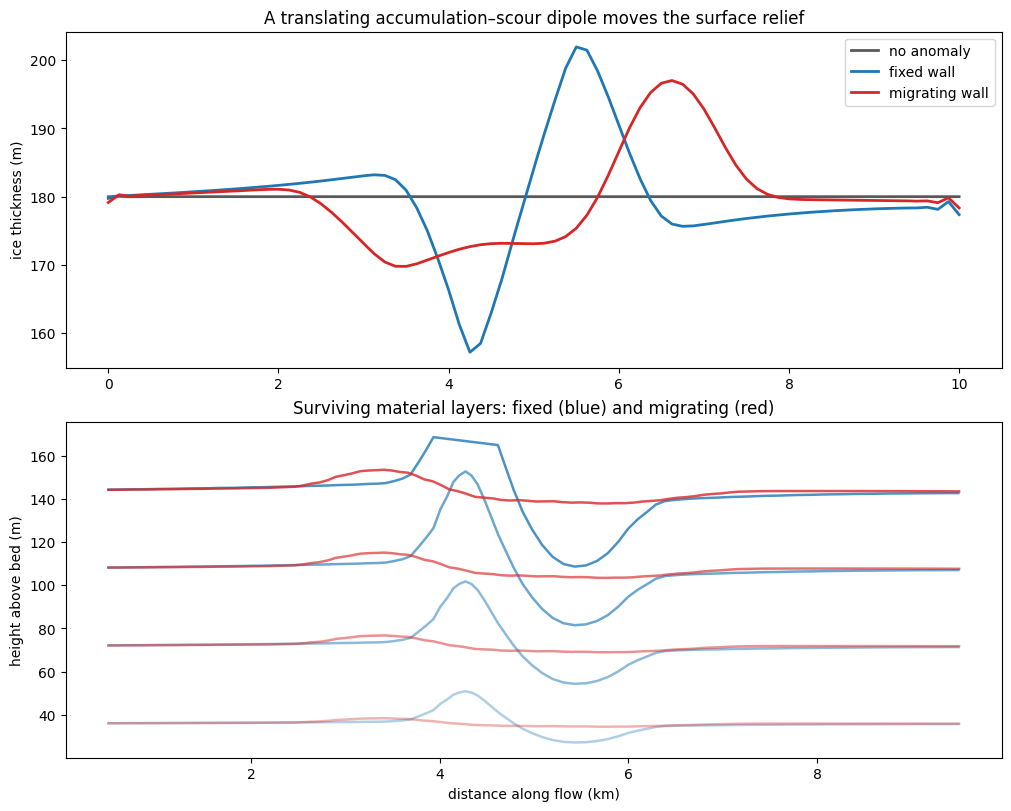

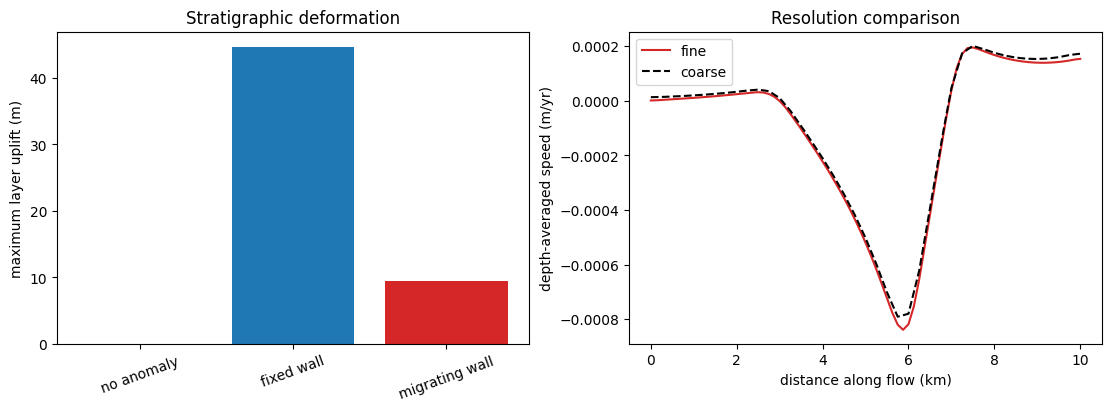

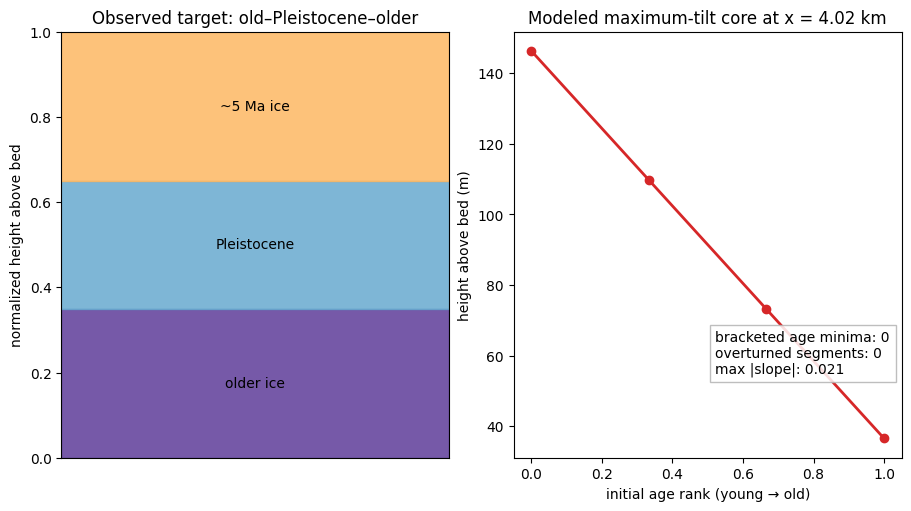

no anomaly      | relief=   0.31 m | peak x= 0.13 km | max uplift=  -0.00 m | max |dz/dx|= 0.0000 | mass closure / initial mass=-4.91e-06
fixed wall      | relief=  44.71 m | peak x= 5.50 km | max uplift=  44.70 m | max |dz/dx|= 0.1246 | mass closure / initial mass=-4.18e-05
migrating wall  | relief=  27.22 m | peak x= 6.62 km | max uplift=   9.48 m | max |dz/dx|= 0.0212 | mass closure / initial mass=-4.74e-05
Prescribed migration distance: 2.94 km over 100 kyr
Factor-of-two resolution differences: relief=0.6%, uplift=1.6%
Vertical-order diagnostic at x=4.02 km: bracketed age minima=0, overturned segments=0

Interpretation:
The moving surface anomaly is tested as a deformation mechanism, not assumed to be the source of the age gap. A continuous initial layer remains continuous unless ablation removes part of it. The modeled core retains monotonically older ice downward, with no Pleistocene age minimum bracketed by older ice. The maximum layer slope is far from vertical and no material 

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import recommended hash")
warnings.filterwarnings("ignore", message="IProgress not found")

from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import firedrake
from firedrake import (
    Constant,
    Function,
    FunctionSpace,
    IntervalMesh,
    SpatialCoordinate,
    assemble,
    dx,
    exp,
)
import icepack

print(f"Icepack {version('icepack')}; Firedrake {version('firedrake')}")

L = 10_000.0
H0 = 180.0
T_TOTAL = 100_000.0
N_STEPS = 50
DT = T_TOTAL / N_STEPS
AMPLITUDE = 8.0e-4
SIGMA = 500.0
OFFSET = 600.0
BACKGROUND_SLOPE = 1.0e-3
CENTER_START = 3_500.0
CENTER_END = 6_500.0
LAYER_FRACTIONS = np.array([0.2, 0.4, 0.6, 0.8])


def sample(field, coordinates):
    points = np.asarray(coordinates, dtype=float).reshape(-1, 1)
    return np.asarray(field.at(points, tolerance=1.0e-8), dtype=float).reshape(-1)


def run_case(name, nx=80, mode="none"):
    mesh = IntervalMesh(nx, L)
    x = SpatialCoordinate(mesh)[0]
    Q = FunctionSpace(mesh, "CG", 1)
    V = FunctionSpace(mesh, "CG", 1)

    bed = Function(Q, name="bed").interpolate(-BACKGROUND_SLOPE * x)
    thickness = Function(Q, name="thickness").interpolate(Constant(H0))
    surface = Function(Q, name="surface").interpolate(thickness + bed)
    velocity = Function(V, name="velocity").interpolate(Constant(0.01))
    accumulation = Function(Q, name="surface_mass_balance")

    model = icepack.models.ShallowIce()
    solver = icepack.solvers.FlowSolver(
        model,
        prognostic_solver_type="implicit-euler",
    )
    fluidity = icepack.rate_factor(Constant(243.15))
    velocity = solver.diagnostic_solve(
        velocity=velocity,
        thickness=thickness,
        surface=surface,
        fluidity=fluidity,
    )

    grid = np.linspace(1.0e-5, L - 1.0e-5, 4 * nx + 1)
    layer_x = np.tile(np.linspace(500.0, L - 500.0, 101), (len(LAYER_FRACTIONS), 1))
    layer_z = LAYER_FRACTIONS[:, None] * H0
    layer_z = np.broadcast_to(layer_z, layer_x.shape).copy()
    alive = np.ones_like(layer_x, dtype=bool)

    initial_mass = assemble(thickness * dx)
    budget = 0.0
    centers = []
    initial_thickness = sample(thickness, grid)

    for step in range(N_STEPS):
        if mode == "none":
            center = 0.5 * L
            accumulation.assign(0.0)
        else:
            fraction = (step + 0.5) / N_STEPS
            if mode == "moving":
                center = CENTER_START + fraction * (CENTER_END - CENTER_START)
            else:
                center = 0.5 * L
            scour = exp(-((x - (center - OFFSET)) / SIGMA) ** 2)
            drift = exp(-((x - (center + OFFSET)) / SIGMA) ** 2)
            accumulation.interpolate(AMPLITUDE * (drift - scour))
        centers.append(center)

        h_grid = sample(thickness, grid)
        u_grid = sample(velocity, grid)
        source = assemble(accumulation * dx)
        left_flux = h_grid[0] * u_grid[0]
        right_flux = h_grid[-1] * u_grid[-1]
        budget += DT * (source + left_flux - right_flux)

        u_x_grid = np.gradient(u_grid, grid)
        particle_x = np.clip(layer_x, grid[0], grid[-1])
        particle_u = np.interp(particle_x, grid, u_grid)
        particle_ux = np.interp(particle_x, grid, u_x_grid)
        layer_x[alive] += DT * particle_u[alive]
        layer_z[alive] += DT * (-layer_z * particle_ux)[alive]

        thickness = solver.prognostic_solve(
            DT,
            thickness=thickness,
            accumulation=accumulation,
            velocity=velocity,
        )
        surface.interpolate(thickness + bed)
        velocity = solver.diagnostic_solve(
            velocity=velocity,
            thickness=thickness,
            surface=surface,
            fluidity=fluidity,
        )

        h_after = sample(thickness, grid)
        clipped_x = np.clip(layer_x, grid[0], grid[-1])
        local_h = np.interp(clipped_x, grid, h_after)
        alive &= (
            (layer_x >= grid[0])
            & (layer_x <= grid[-1])
            & (layer_z >= 0.0)
            & (layer_z <= local_h)
        )

    final_thickness = sample(thickness, grid)
    final_velocity = sample(velocity, grid)
    final_mass = assemble(thickness * dx)
    mass_change = final_mass - initial_mass
    mass_residual = (mass_change - budget) / initial_mass

    uplift = []
    tilt = []
    for index, fraction in enumerate(LAYER_FRACTIONS):
        mask = alive[index]
        if np.count_nonzero(mask) > 4:
            uplift.append(np.nanmax(layer_z[index, mask] - fraction * H0))
            order = np.argsort(layer_x[index, mask])
            x_line = layer_x[index, mask][order]
            z_line = layer_z[index, mask][order]
            tilt.append(np.nanmax(np.abs(np.gradient(z_line, x_line))))
        else:
            uplift.append(np.nan)
            tilt.append(np.nan)

    return {
        "name": name,
        "nx": nx,
        "mode": mode,
        "grid": grid,
        "initial_thickness": initial_thickness,
        "thickness": final_thickness,
        "velocity": final_velocity,
        "layer_x": layer_x,
        "layer_z": layer_z,
        "alive": alive,
        "wall_relief": float(np.max(final_thickness) - np.min(final_thickness)),
        "peak_position": float(grid[np.argmax(final_thickness)]),
        "max_uplift": float(np.nanmax(uplift)),
        "max_tilt": float(np.nanmax(tilt)),
        "mass_residual": float(mass_residual),
        "mass_change": float(mass_change),
        "budget": float(budget),
        "center_distance": float(centers[-1] - centers[0]),
    }


cases = {
    "no anomaly": run_case("no anomaly", nx=80, mode="none"),
    "fixed wall": run_case("fixed wall", nx=80, mode="fixed"),
    "migrating wall": run_case("migrating wall", nx=80, mode="moving"),
}
coarse = run_case("migrating wall, coarse", nx=40, mode="moving")

fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)
colors = {"no anomaly": "0.35", "fixed wall": "tab:blue", "migrating wall": "tab:red"}
for label, result in cases.items():
    axes[0].plot(
        result["grid"] / 1000,
        result["thickness"],
        color=colors[label],
        label=label,
        linewidth=2,
    )
axes[0].set(
    ylabel="ice thickness (m)",
    title="A translating accumulation–scour dipole moves the surface relief",
)
axes[0].legend()

for label in ("fixed wall", "migrating wall"):
    result = cases[label]
    for layer_index, fraction in enumerate(LAYER_FRACTIONS):
        mask = result["alive"][layer_index]
        axes[1].plot(
            result["layer_x"][layer_index, mask] / 1000,
            result["layer_z"][layer_index, mask],
            color=colors[label],
            alpha=0.35 + 0.15 * layer_index,
            linewidth=1.8,
        )
axes[1].set(
    xlabel="distance along flow (km)",
    ylabel="height above bed (m)",
    title="Surviving material layers: fixed (blue) and migrating (red)",
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
labels = ["no anomaly", "fixed wall", "migrating wall"]
axes[0].bar(
    labels,
    [cases[label]["max_uplift"] for label in labels],
    color=[colors[label] for label in labels],
)
axes[0].set(ylabel="maximum layer uplift (m)", title="Stratigraphic deformation")
axes[0].tick_params(axis="x", rotation=20)
axes[1].plot(
    cases["migrating wall"]["grid"] / 1000,
    cases["migrating wall"]["velocity"],
    color="tab:red",
    label="fine",
)
axes[1].plot(
    coarse["grid"] / 1000,
    coarse["velocity"],
    color="k",
    linestyle="--",
    label="coarse",
)
axes[1].set(xlabel="distance along flow (km)", ylabel="depth-averaged speed (m/yr)", title="Resolution comparison")
axes[1].legend()
plt.show()

fine = cases["migrating wall"]
scan_x = np.linspace(1_000.0, 9_000.0, 401)
core_heights = np.full((len(LAYER_FRACTIONS), len(scan_x)), np.nan)
core_slopes = np.full_like(core_heights, np.nan)
for layer_index in range(len(LAYER_FRACTIONS)):
    mask = fine["alive"][layer_index]
    x_line = fine["layer_x"][layer_index, mask]
    z_line = fine["layer_z"][layer_index, mask]
    order = np.argsort(x_line)
    x_line = x_line[order]
    z_line = z_line[order]
    inside = (scan_x >= x_line[0]) & (scan_x <= x_line[-1])
    core_heights[layer_index, inside] = np.interp(scan_x[inside], x_line, z_line)
    segment_slope = np.gradient(z_line, x_line)
    core_slopes[layer_index, inside] = np.interp(scan_x[inside], x_line, segment_slope)

valid_core = np.all(np.isfinite(core_heights), axis=0)
tilt_score = np.nanmax(np.abs(core_slopes), axis=0)
core_index = np.nanargmax(np.where(valid_core, tilt_score, np.nan))
core_x = scan_x[core_index]
core_z = core_heights[:, core_index]
age_rank = (LAYER_FRACTIONS.max() - LAYER_FRACTIONS) / np.ptp(LAYER_FRACTIONS)
bracketed_age_minima = sum(
    age_rank[index] < age_rank[index - 1] and age_rank[index] < age_rank[index + 1]
    for index in range(1, len(age_rank) - 1)
)
overturned_segments = sum(
    np.count_nonzero(np.diff(fine["layer_x"][index, fine["alive"][index]]) <= 0.0)
    for index in range(len(LAYER_FRACTIONS))
)

fig, axes = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True)
target_bands = [
    (0.00, 0.35, "older ice", "#5e3c99"),
    (0.35, 0.65, "Pleistocene", "#67a9cf"),
    (0.65, 1.00, "~5 Ma ice", "#fdb863"),
]
for lower, upper, label, color in target_bands:
    axes[0].axhspan(lower, upper, color=color, alpha=0.85)
    axes[0].text(0.5, 0.5 * (lower + upper), label, ha="center", va="center")
axes[0].set(
    xlim=(0, 1), ylim=(0, 1), xticks=[], ylabel="normalized height above bed",
    title="Observed target: old–Pleistocene–older",
)
axes[1].plot(age_rank, core_z, "o-", color="tab:red", linewidth=2)
axes[1].set(
    xlim=(-0.05, 1.05), xlabel="initial age rank (young → old)",
    ylabel="height above bed (m)",
    title=f"Modeled maximum-tilt core at x = {core_x / 1000:.2f} km",
)
axes[1].text(
    0.52, 0.30,
    f"bracketed age minima: {bracketed_age_minima}\n"
    f"overturned segments: {overturned_segments}\n"
    f"max |slope|: {tilt_score[core_index]:.3f}",
    transform=axes[1].transAxes, va="top",
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
)
plt.show()

relief_error = abs(coarse["wall_relief"] - fine["wall_relief"]) / max(abs(fine["wall_relief"]), 1.0e-12)
uplift_error = abs(coarse["max_uplift"] - fine["max_uplift"]) / max(abs(fine["max_uplift"]), 1.0e-12)

for label, result in cases.items():
    print(
        f"{label:15s} | relief={result['wall_relief']:7.2f} m "
        f"| peak x={result['peak_position']/1000:5.2f} km "
        f"| max uplift={result['max_uplift']:7.2f} m "
        f"| max |dz/dx|={result['max_tilt']:7.4f} "
        f"| mass closure / initial mass={result['mass_residual']:+.2e}"
    )
print(f"Prescribed migration distance: {fine['center_distance']/1000:.2f} km over {T_TOTAL/1000:.0f} kyr")
print(f"Factor-of-two resolution differences: relief={relief_error:.1%}, uplift={uplift_error:.1%}")
print(
    f"Vertical-order diagnostic at x={core_x/1000:.2f} km: "
    f"bracketed age minima={bracketed_age_minima}, overturned segments={overturned_segments}"
)

print("\nInterpretation:")
print(
    "The moving surface anomaly is tested as a deformation mechanism, not assumed to be the source of the age gap. "
    "A continuous initial layer remains continuous unless ablation removes part of it. "
    "The modeled core retains monotonically older ice downward, with no Pleistocene age minimum bracketed by older ice. "
    "The maximum layer slope is far from vertical and no material segment overturns. In Waddington's terms, the "
    "depth-averaged plug-flow model tilts a seed but supplies no vertical shear to turn it into a recumbent fold. "
    "Migration alone therefore fails to make old ice over Pleistocene ice; it would need a pre-existing overturned "
    "fold, thrust, or unconformity and a mechanism that preserves older ice below."
)


## Decision rule

The migrating-wall hypothesis gains support only if migration produces materially more layer deformation than the fixed-wall control while conserving mass and remaining stable to the resolution check. It must ultimately create a vertical old–Pleistocene–older sequence, not a lateral contact or a tilted monotonic section. In the present plug-flow calculation, zero overturned segments and zero bracketed age minima reject migration as a complete mechanism. A later model should add depth-dependent shear and integrate the deformation gradient along the seeded wrinkle, following Waddington et al. (2001).